In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

from symmlearn.lattice._structure_dict import get_structure_letters

In [2]:
def estimate_max_counts(pg_num, minimum = 20, maximum = 500, min_counts = 8, max_counts = 20):
    """
    Estimate optimal counts parameter for get_structure_letters function.
    
    Searches for the counts value (between min_counts and max_counts) that yields
    a number of combinations closest to the midpoint of [minimum, maximum] range.
    
    Args:
        pg_num: Page number identifier for structure generation
        minimum: Minimum acceptable number of combinations (lower bound)
        maximum: Maximum acceptable number of combinations (upper bound)
        min_counts: Minimum counts parameter to try
        max_counts: Maximum counts parameter to try
        
    Returns:
        Optimal counts parameter that produces number of combinations
        closest to target range midpoint
    """
    # Store number of combinations for each counts value
    combination_counts = []
    
    # Test each possible counts value in range
    for counts in range(min_counts, max_counts + 1):
        combinations = get_structure_letters(pg_num=pg_num, max_counts=counts)
        combination_counts.append(len(combinations))
    
    combination_counts = np.array(combination_counts)
    
    # Case 1: All counts produce too many combinations
    if combination_counts.min() >= maximum:
        return min_counts  # Use smallest counts to minimize combinations
        
    # Case 2: All counts produce too few combinations
    elif combination_counts.max() <= minimum:
        return max_counts  # Use largest counts to maximize combinations
        
    # Case 3: Find counts producing combinations closest to target midpoint
    else:
        target = (minimum + maximum) // 2
        deviations = np.abs(combination_counts - target)
        optimal_index = np.argmin(deviations)
        
        # Map index back to original counts value
        possible_counts = list(range(min_counts, max_counts + 1))
        optimal_counts = possible_counts[optimal_index]
        
        return optimal_counts

In [3]:
#calculate max atoms counts for each pg numbers
pg_nums = range(1,18)
max_counts = []
for pg_num in pg_nums:
    max_count = estimate_max_counts(pg_num=pg_num)
    max_counts.append(max_count)
max_counts = np.array(max_counts)

In [4]:
#calcualte all possible structures based on max_counts
structures_dict = {}
for pg_num in pg_nums:
    structures_dict[pg_num] = []
for pg_num,count in zip(pg_nums,max_counts):
    structures = get_structure_letters(pg_num=pg_num, max_counts=count)
    for letters in structures:
        structures_dict[pg_num].append(letters)

In [5]:
for pg_num in pg_nums:
    print(f'Plane group {pg_num} has {len(structures_dict[pg_num])} structures.')

Plane group 1 has 20 structures.
Plane group 2 has 155 structures.
Plane group 3 has 251 structures.
Plane group 4 has 10 structures.
Plane group 5 has 35 structures.
Plane group 6 has 565 structures.
Plane group 7 has 120 structures.
Plane group 8 has 20 structures.
Plane group 9 has 160 structures.
Plane group 10 has 40 structures.
Plane group 11 has 257 structures.
Plane group 12 has 38 structures.
Plane group 13 has 54 structures.
Plane group 14 has 123 structures.
Plane group 15 has 59 structures.
Plane group 16 has 26 structures.
Plane group 17 has 73 structures.


In [6]:
counts = [len(structures_dict[pg_num]) for pg_num in pg_nums]

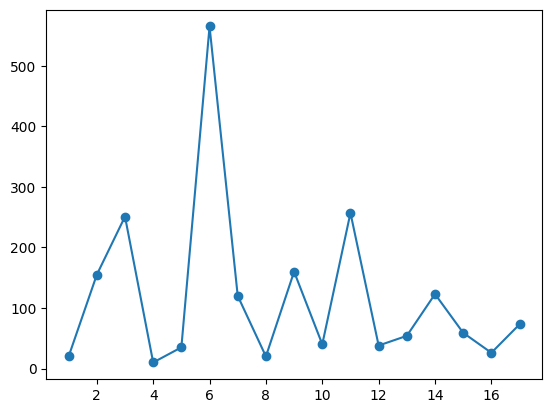

In [7]:
plt.plot(pg_nums,counts,'o-')

In [9]:
## save structure under '.\\data' path
def save_structures(name = 'structure_data'):
    current_folder = os.getcwd()
    parent = os.path.dirname(current_folder)
    structure_data_path = parent+f"\\data\\structure data\\{name}.pkl"
    with open(structure_data_path, "wb") as f:
        pickle.dump(structures_dict, f)